# **Análisis exploratorio de datos (EDA)**: The Complete Pokemon Dataset

## Desafío inicial: ¿Dos Pokémon con un poder total similar son necesariamente similares?

## Pregunta de investigación: ¿Es posible construir un clasificador para identificar Pokémon Legendarios?

###En este dataset se encuentra información estadística de los poderes de 801 Pokemón de las 7 generaciones. En cada fila encontramos un Pokemón distinto, y cada columna es una característica distinta, dentro de las características generales podemos encontrar; nombre, tipo 1 y 2 del Pokemón, altura, estatura, generación, si es legendario, etc. Por otra parte, los Pokemón realizan combates entre ellos, por lo que existen columnas que indican puntos que suman a su poder total, como; hp, ataque, defensa, velocidad, ataque especial y defensa especial. Algunas de las columnas contienen valores faltantes, como; peso, estatura, porcentaje de especies masculinas, o tipo secundario del Pokemón, estas 2 últimas están vacías porque el Pokemón no tiene genero, o no tiene tipo secundario respectivamente.

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = kagglehub.dataset_download("rounakbanik/pokemon")
ruta_archivo = os.path.join(path, "pokemon.csv")
df = pd.read_csv(ruta_archivo)

Using Colab cache for faster access to the 'pokemon' dataset.


###En el siguiente código podemos observar todas las columnas existentes de nuestro catálogo.

In [ ]:
df.columns

Index(['abilities', 'against_bug', 'against_dark', 'against_dragon',
       'against_electric', 'against_fairy', 'against_fight', 'against_fire',
       'against_flying', 'against_ghost', 'against_grass', 'against_ground',
       'against_ice', 'against_normal', 'against_poison', 'against_psychic',
       'against_rock', 'against_steel', 'against_water', 'attack',
       'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate',
       'classfication', 'defense', 'experience_growth', 'height_m', 'hp',
       'japanese_name', 'name', 'percentage_male', 'pokedex_number',
       'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg',
       'generation', 'is_legendary'],
      dtype='object')

###Y conocer sus dimensiones.

In [ ]:
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (801, 41)


###Analizamos si es que hay columnas sin información

In [ ]:
nulos = df.isnull().sum()
nulos_filtrados = nulos[nulos > 0]
nulos_filtrados

,0
height_m,20
percentage_male,98
type2,384
weight_kg,20


###Observamos las columnas y sus valores para cada Pokemón. Esto nos sirve para entender el tipo de dato de nuestras columnas.

In [ ]:
pd.set_option('display.max_columns', None)

display(df.head(3))

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1.0,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2.0,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100.0,1,0


#**Parte I: Pregunta de investigación**

### Para conocer las relaciones entre características de Pokemón realizamos una serie de gráficos comparando densidades de distinas columnas. En este análisis exploratorio buscaremos responder a nuestra pregunta de base: ¿Es posible construir un clasificador para identificar Pokémon Legendarios?

###Primero visualizamos la cantidad de Pokémon según sus tipos primarios, en donde se muestra bastante variedad para todos los tipos.

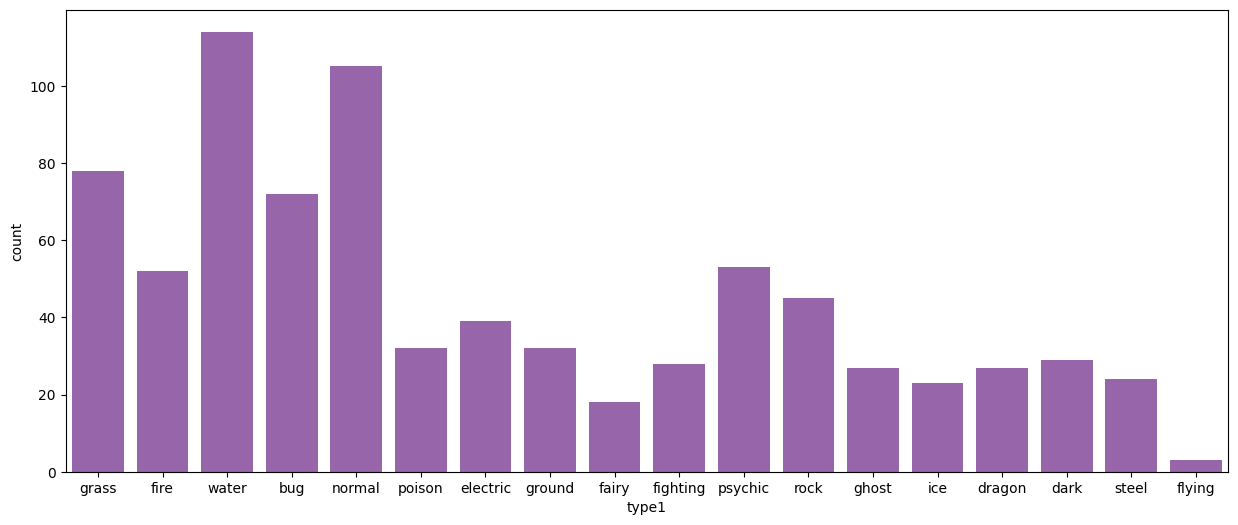

In [ ]:
plt.figure(figsize=(15, 6))

sns.countplot(data=df, x="type1", color="#9b59b6")
plt.show()

###Visualizamos la cantidad de Pokémon en cada generación, obteniendo cantidades similares para cada una.


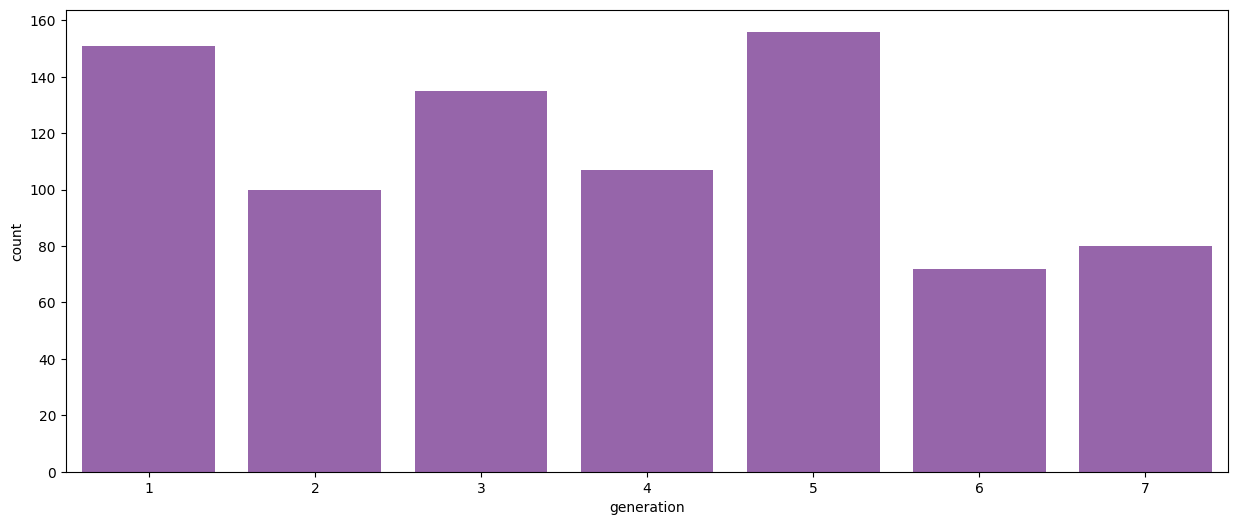

In [ ]:
plt.figure(figsize=(15, 6))

sns.countplot(data=df, x="generation", color="#9b59b6")
plt.show()

###Visualizamos la cantidad de Pokémon según los rangos de poder total, en donde se muestran 2 picos de densidad en distinto poder.

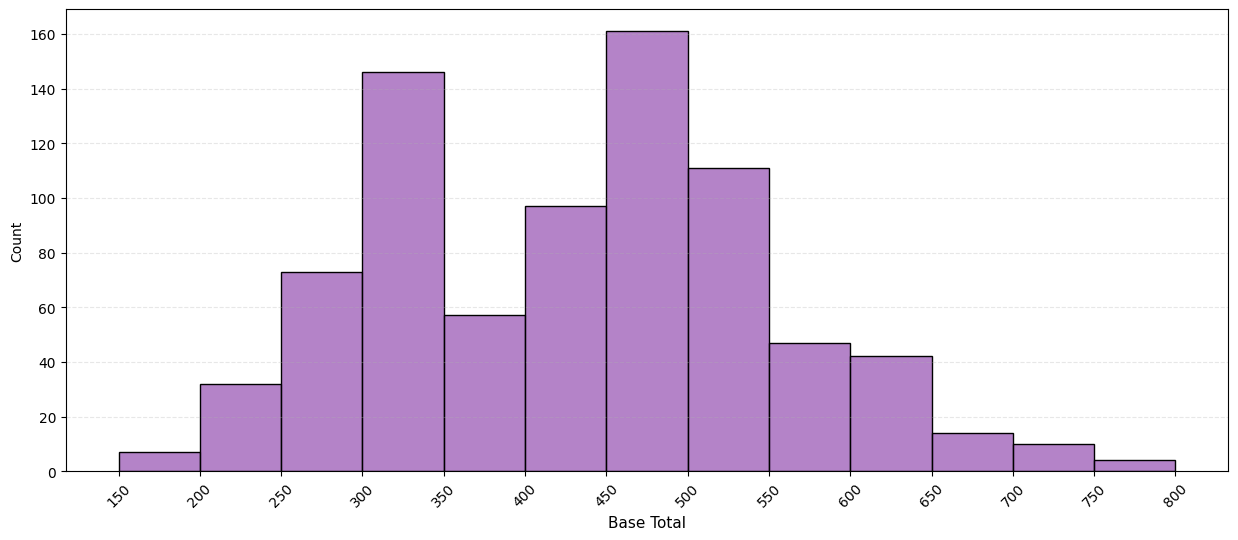

In [ ]:
plt.figure(figsize=(15, 6))

sns.histplot(data=df, x='base_total', binwidth=50, binrange=(150, 800), color="#9b59b6")

plt.xticks(np.arange(150, 801, 50), rotation=45)
plt.xlabel('Base Total', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.show()

### Al separar la muestra de distribución de poder total en si es legendario u ordinario se observa una clara separación, en donde los que son legendarios tienen en promedio un mayor poder total que los que no son legendarios.

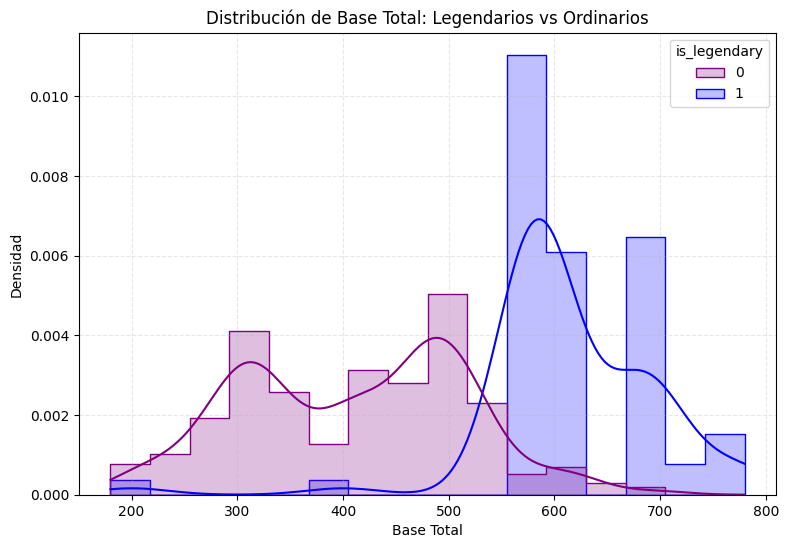

In [ ]:
plt.figure(figsize=(9, 6))
sns.histplot(data=df, x='base_total', hue='is_legendary', element='step', stat='density', common_norm=False, palette={0: 'purple', 1: 'blue'},kde=True)

plt.title('Distribución de Base Total: Legendarios vs Ordinarios')
plt.xlabel('Base Total', fontsize=10)
plt.ylabel('Densidad', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

###Para determinar si las estadísticas individuales pueden separar a los Pokémon Legendarios de los ordinarios más allá del poder total, evaluamos esta matriz de dispersión que analiza las relaciones cruzadas y las distribuciones de densidad entre los seis stats base.

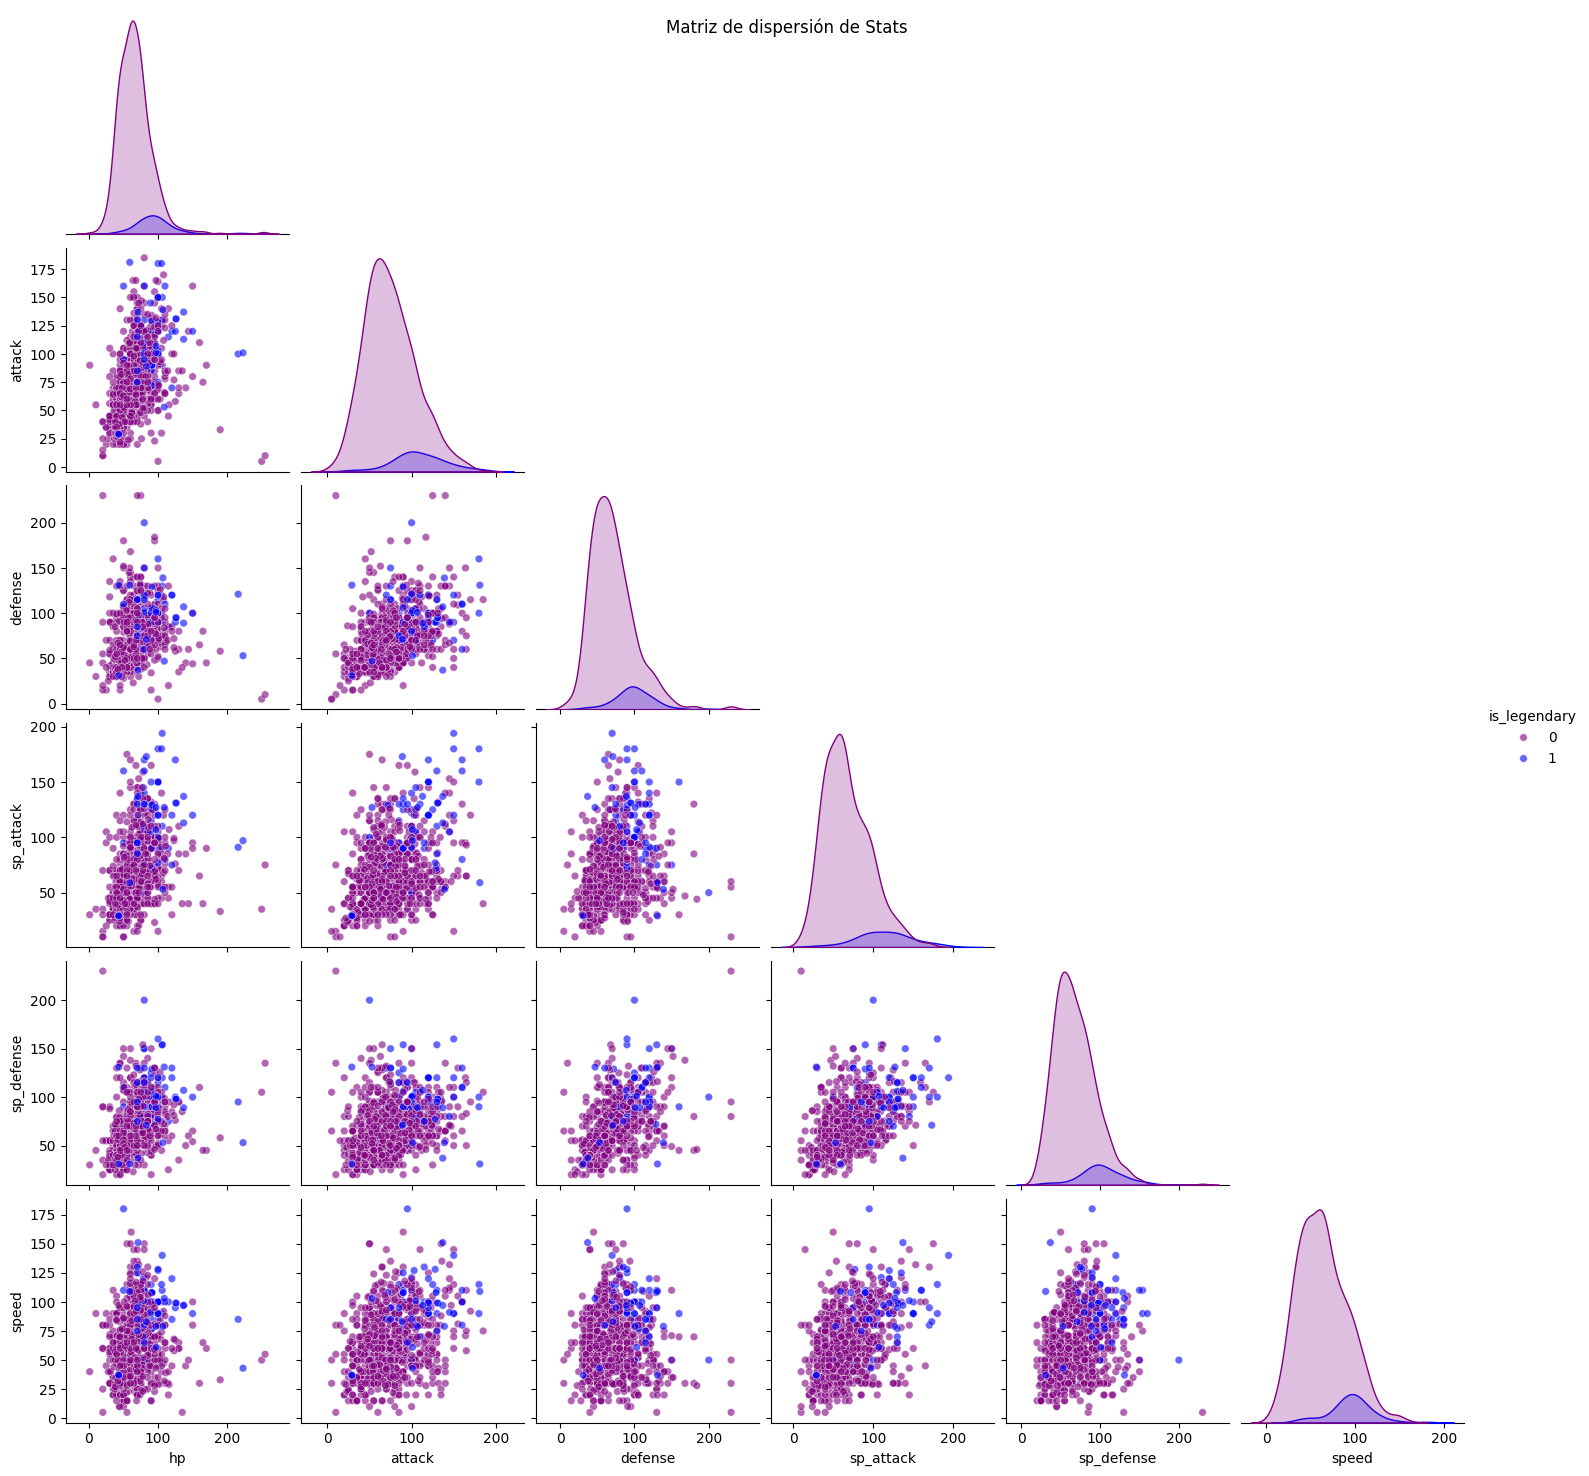

In [ ]:
stats_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'is_legendary']

sns.pairplot(df[stats_cols], hue='is_legendary', corner=True, palette={0: 'purple', 1: 'blue'},plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle('Matriz de dispersión de Stats')
plt.show()

###La matriz revela que los Pokémon Legendarios en azul ocupan una región distintiva en el espacio de características, ubicándose en la parte superior derecha de casi todos los cruces de variables. Aunque existe una superposición con los ordinarios en zonas de valores medios, la combinación de estos seis gráficos ofrece suficientes patrones lineales y no lineales para que un clasificador como un Árbol de Decisión, diferencie exitosamente a ambas clases.

###Consideramos la matriz anterior como la figura clave para nuestra investigación.
*  ### Esta responde a la pregunta de como se dividen las clases de Pokemón legendario y ordinario en función de las características del Pokemón.
* ### Muestra un patrón claro en su dsitribución de clases, colocando al Pokemón legendario en la esquina superior derecha de los datos para cada característica.
* ### Esta figura es importante para nuestra investigación, ya que demarca una separación de clases suficiente para que un algorítmo clasificador de Machine Learning replique este resultado eventualmente.

### Luego realizamos una matriz de correlación que nos muestra como se relacionan las características de cada Pokemón. Observamos una baja correlación entre la mayoría de las características. Sin embargo, la que mayor correlación tiene con el Pokemón legendario es el esfuerzo de crianza.

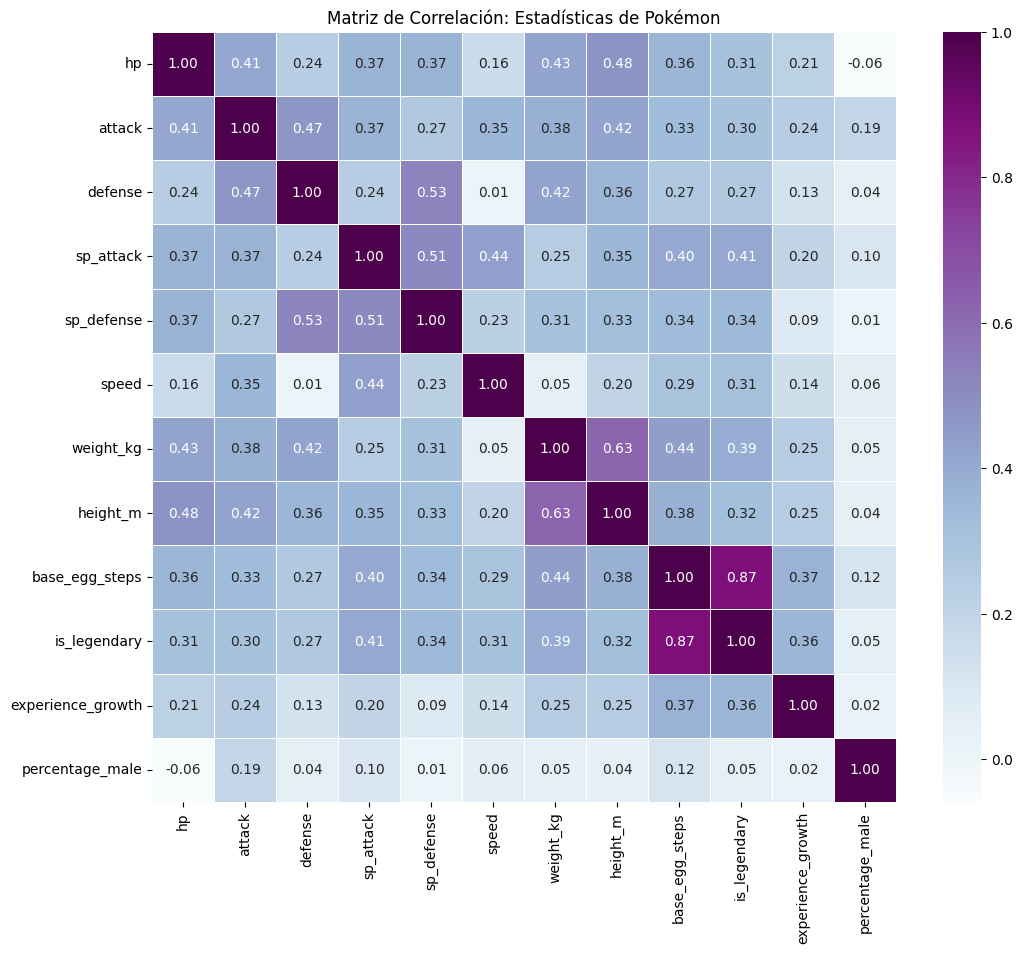

In [ ]:
plt.figure(figsize=(12, 10))

cols_numericas = df[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'weight_kg', 'height_m', 'base_egg_steps','is_legendary','experience_growth','percentage_male']]

matriz_corr = cols_numericas.corr()

sns.heatmap(matriz_corr, annot=True, cmap='BuPu', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Estadísticas de Pokémon')
plt.show()

###Comparamos como se comportan las características generales para Pokemón legendario y ordinario, y observamos que para todas las características siempre tiene más puntos un Pokemón legendario.

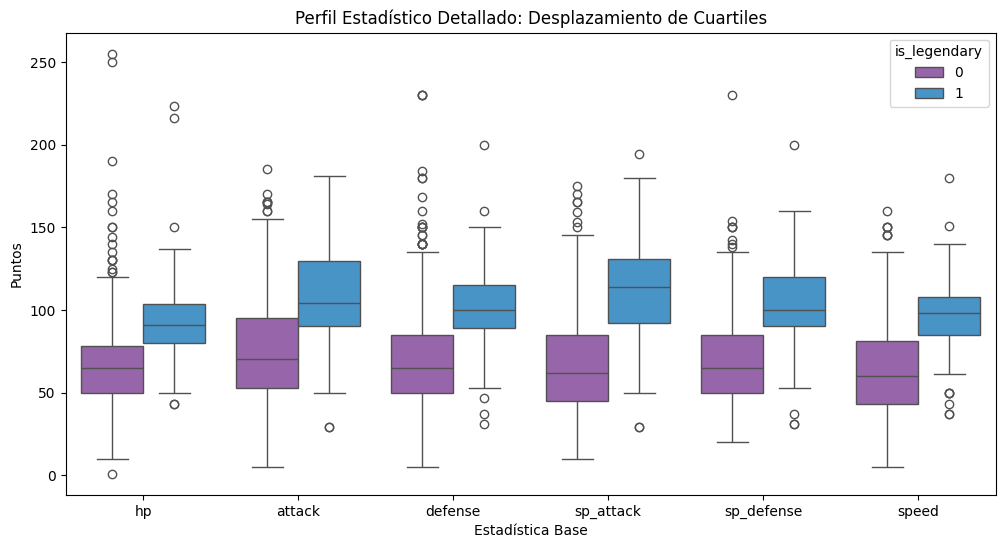

In [ ]:
plt.figure(figsize=(12, 6))

columnas_combate = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
df_melt = df.melt(id_vars=['name', 'is_legendary'], value_vars=columnas_combate, var_name='Estadística', value_name='Puntos')

sns.boxplot(data=df_melt, x='Estadística', y='Puntos', hue='is_legendary', palette=['#9b59b6', '#3498db'])

plt.title('Perfil Estadístico Detallado: Desplazamiento de Cuartiles')
plt.xlabel('Estadística Base')
plt.ylabel('Puntos')
plt.show()

###Por otra parte si comparamos el esfuerzo de crianza para ambos tipos de Pokemón, legendario y ordinario notamos una clara diferencia, en donde la cantidad de esfuerzo para obtener un Pokemón legendario es mucho mayor que para obtener un Pokemón no legendario.

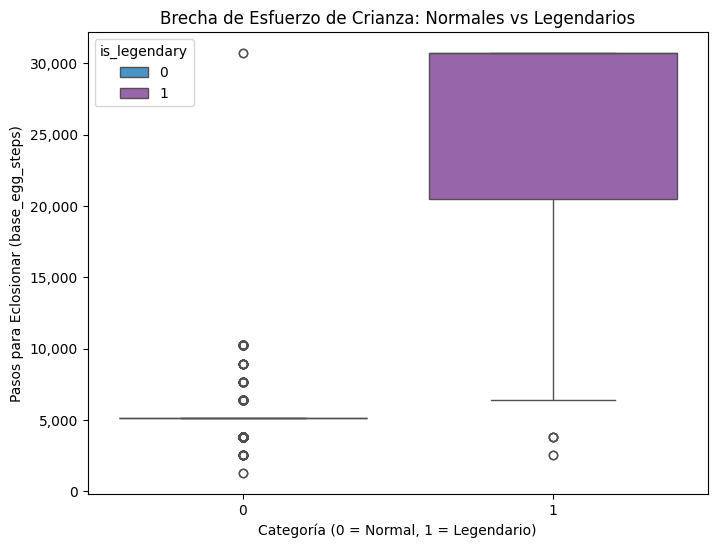

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=df,x='is_legendary',y='base_egg_steps',hue='is_legendary',palette=['#3498db', '#9b59b6'])

plt.title('Brecha de Esfuerzo de Crianza: Normales vs Legendarios')
plt.xlabel('Categoría (0 = Normal, 1 = Legendario)')
plt.ylabel('Pasos para Eclosionar (base_egg_steps)')

plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

#**Resultado inesperado I**

* ### Observación: Existe una gran brecha entre el promedio de esfuerzo de crianza para Pokemón legendario y ordinario.
* ### Hiṕotesis: Esta brecha puede deberse a que el juego está hecho de manera que la persona deba esforzarse más para obtener un Pokemón Legendario.
* ### Evidencia adicional: Podríamos disponer de una nueva columna que indique la cantidad de tiempo (o pasos) que la persona jugó para obtener un Pokemón legendario.

#**Parte II: Pregunta Desafío**

### Ahora buscaremos responder el desafío inicial: ¿Dos Pokémon con un poder total similar son necesariamente similares? Para esto seleccionamos como ejemplo a todos los Pokémon que tengan un poder total igual a 505 y comparamos sus valores de Stats

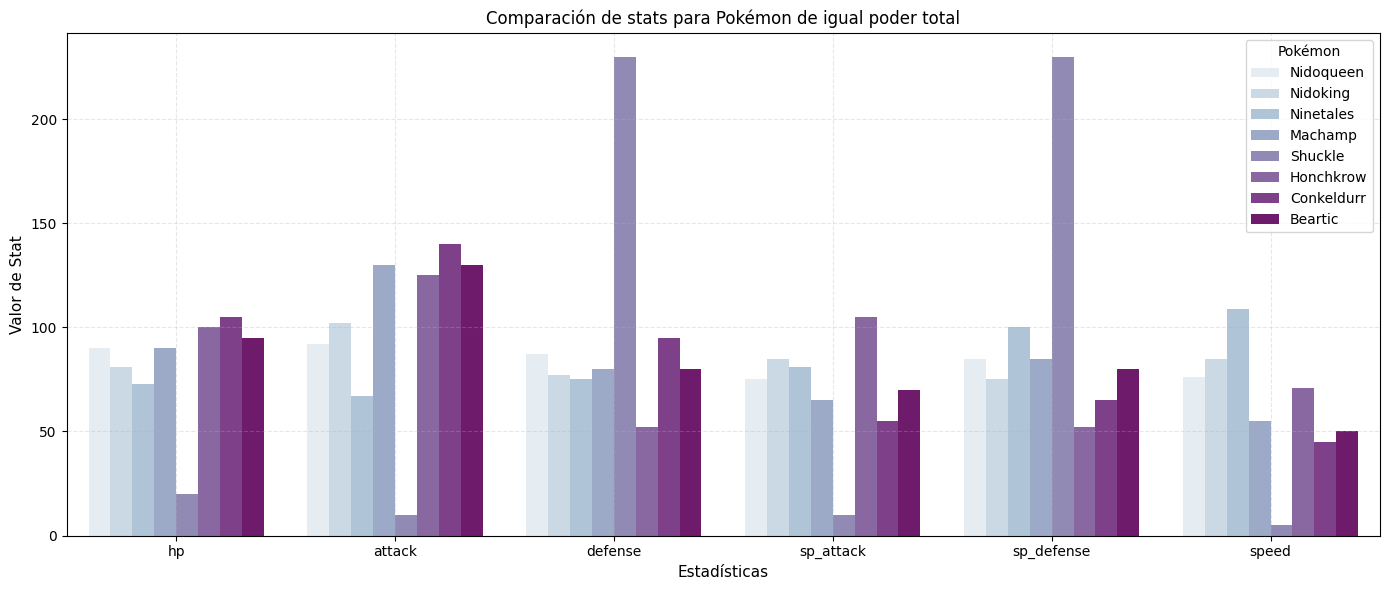

In [ ]:
grupo_505 = df[df['base_total'] == 505]

stats_melted = grupo_505.melt(id_vars=['name'], value_vars=['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed'], var_name='Estadística', value_name='Valor')

plt.figure(figsize=(14, 6))
sns.barplot(data=stats_melted, x='Estadística', y='Valor', hue='name', palette='BuPu')

plt.title('Comparación de stats para Pokémon de igual poder total')
plt.xlabel('Estadísticas', fontsize=11)
plt.ylabel('Valor de Stat', fontsize=11)

plt.legend(title='Pokémon')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

###El gráfico demuestra que poseer un mismo valor de poder total como 505, no garantiza ninguna similitud entre los Pokémon, ya que cada uno distribuye su presupuesto estadístico de manera completamente distinta. Mientras que un caso extremo como Shuckle que sacrifica prácticamente toda su Salud, Ataque y Velocidad para concentrar valores en su defensa y defensa especial, otros Pokémon optan por perfiles totalmente diferentes como Machamp y Conkeldurr que concentran su presupuesto hacia el ataque, manteniendo equiparados sus valores en los demás atributos, y Ninetales que reparte sus puntos priorizando la Velocidad y el Ataque Especial. Por lo que, a partir de este gráfico podemos concluir que la suma total de estadísticas, correspondientes al poder total, actúa únicamente como un límite de poder, pero es la asignación individual de cada atributo la que define la verdadera identidad y rol del Pokémon.

#**Resultado inesperado II**

* ### Observación: Dentro del grupo de Pokémon con un poder total idéntico de 505, Shuckle presenta una distribución de estadísticas extremas totalmente atípica ya que concentra casi la totalidad de sus puntos en defensa y defensa especial, ambas sobre los 230 puntos, reduciendo a valores marginales cercanos a 10 o 20 puntos sus demás atributos.
* ### Hipótesis: Diseñar estadísticas tan extremas responde a la creación de un Pokémon especial puramente defensivo, donde se sacrifica por completo la capacidad ofensiva y la movilidad para actuar como una barrera que resista ataques dentro de la dinámica de combate.
* ### Evidencia adicional: Revisar su lista de movimientos aprendibles para ver si los datos muestran que Shuckle aprende prioritariamente movimientos de estado o desgaste en lugar de ataques directos de daño, así se demostraría que sus estadísticas de ataque nulas y sus defensas extremas fueron diseñadas intencionalmente para un rol defensivo.

### A continuación, vemos una tabla que compara el tipo primario y tipo secundario de los Pokémon con igual poder total de 505

In [ ]:
resumen_tipos = grupo_505[['name', 'type1', 'type2']].reset_index(drop=True)
resumen_tipos.columns = ['Pokémon', 'Tipo Primario', 'Tipo Secundario']
print(resumen_tipos)

      Pokémon Tipo Primario Tipo Secundario
0   Nidoqueen        poison          ground
1    Nidoking        poison          ground
2   Ninetales          fire             ice
3     Machamp      fighting             NaN
4     Shuckle           bug            rock
5   Honchkrow          dark          flying
6  Conkeldurr      fighting             NaN
7     Beartic           ice             NaN


###La combinación de tipos elementales refuerza aún más su individualidad funcional. La tabla evidencia una amplia diversidad tipológica donde conviven especies de distintos tipos y combinaciones. Pero vemos que Nidoqueen y Nidoking comparten ambos tipos y en el gráfico de stats no presentan una gran diferencia en sus proporciones, de igual manera con Machamp y Conkeldurr, que comparten su único tipo primario, vemos que sus valores de stats no se alejan mucho entre sí. Aun así, esta dispersión de tipos primarios y secundarios demuestra que compartir un mismo presupuesto de poder no impone ninguna restricción en la identidad elemental.

###Evaluamos la distribución de estadísticas para los Pokémon de igual poder total, en este cado de 500, segmentada por generación para determinar si la variabilidad en los perfiles se mantiene constante o evoluciona con el progreso del juego.

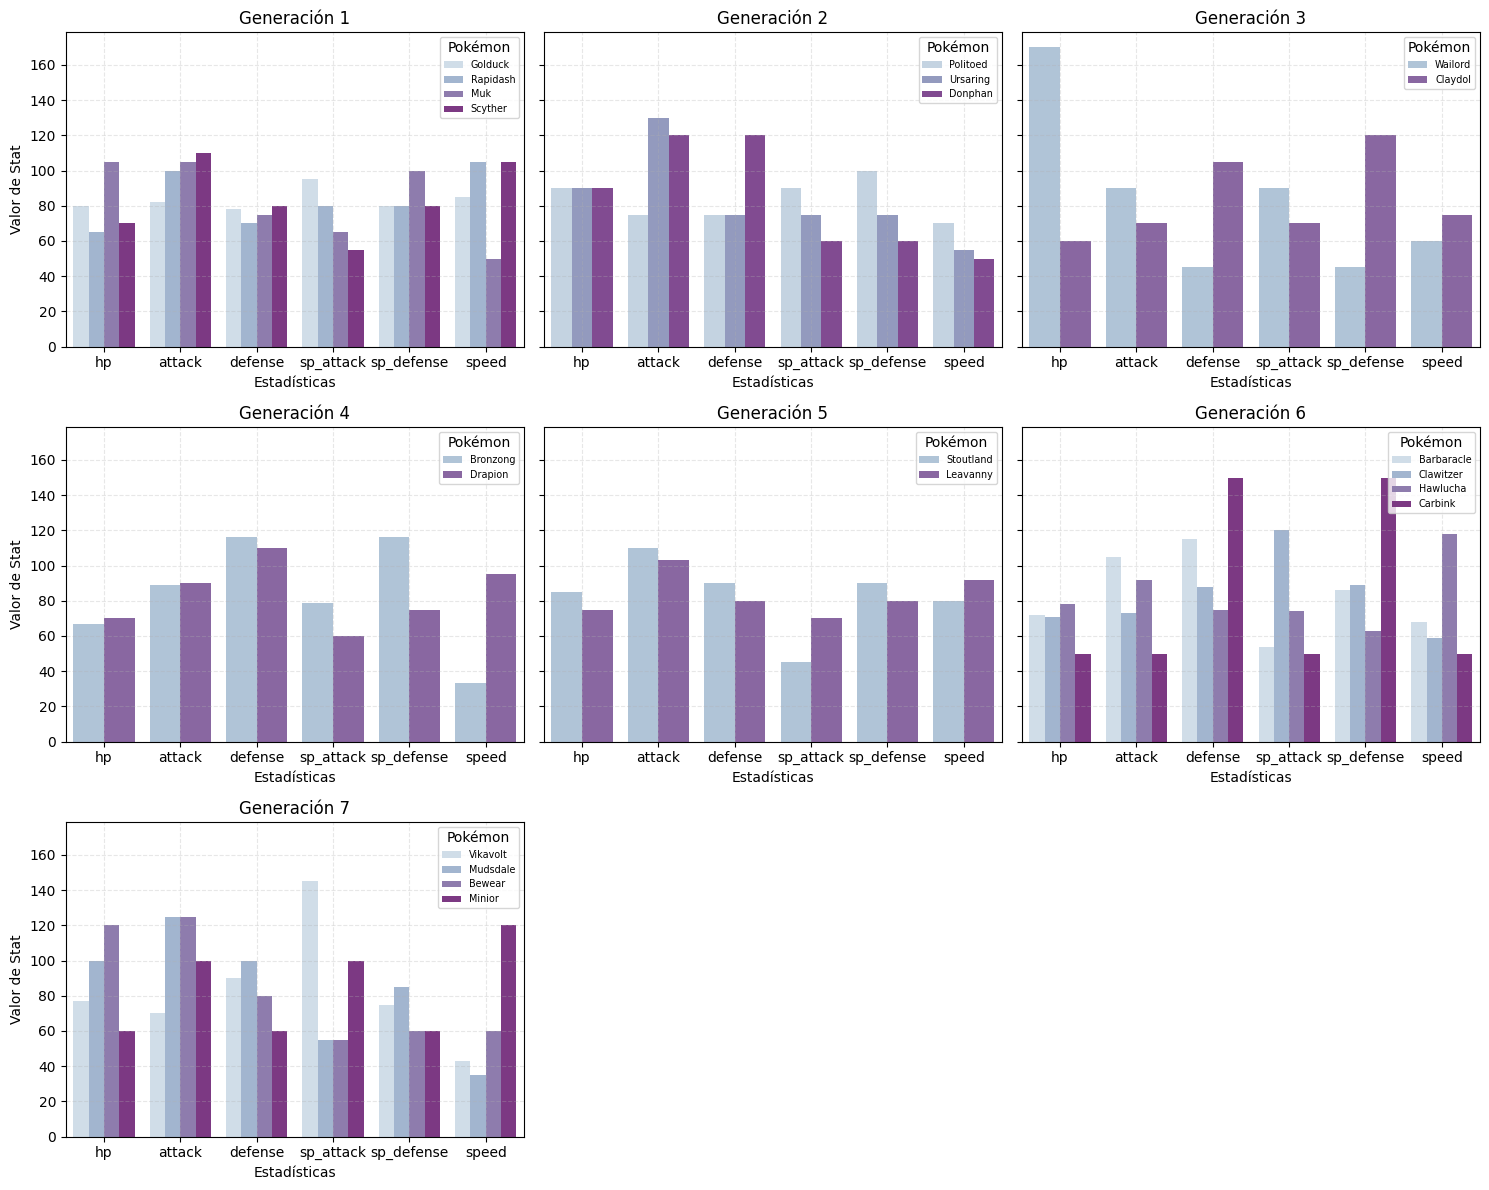

In [ ]:
PODER_OBJETIVO = 500
grupo_filtrado = df[df['base_total'] == PODER_OBJETIVO].copy()

stats_melted = grupo_filtrado.melt(
    id_vars=['name', 'generation'],
    value_vars=['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed'],
    var_name='Estadística',
    value_name='Valor'
)

generaciones = sorted(stats_melted['generation'].unique())
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharey=True)
axes = axes.flatten()

for i, gen in enumerate(generaciones):
    ax = axes[i]
    data_gen = stats_melted[stats_melted['generation'] == gen]

    sns.barplot(data=data_gen, x='Estadística', y='Valor', hue='name', ax=ax, palette='BuPu')

    ax.set_title(f'Generación {gen}')
    ax.set_xlabel('Estadísticas')
    ax.set_ylabel('Valor de Stat' if i % 3 == 0 else '')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(title='Pokémon', loc='upper right', fontsize='x-small')

for j in range(len(generaciones), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

###Este gráfico, reafirma que la individualidad en la distribución de estadísticas para un mismo valor de poder total es un principio que se mantiene en las siete generaciones. El análisis de las siete generaciones demuestra que tener los mismos 500 puntos de poder total solo fija un límite, pero no hace que los Pokémon se parezcan entre sí. Mientras que las primeras generaciones creaban Pokémon más parejos como Golduck o Politoed, las generaciones más nuevas apostaron por Pokémon mucho más especializados, como Wailord con su enorme cantidad de vida, Carbink enfocado solo en defender o Vikavolt con un ataque especial muy alto. Esto nos confirma que la generación no cambia las reglas del juego ni mezcla los datos de forma extraña, por lo que un modelo de Machine Learning podrá aprender a identificar a los Legendarios usando las estadísticas individuales de cada Pokémon sin importar de qué generación sea.

In [ ]:
grupo_500 = df[df['base_total'] == 500].copy()
grupo_500['type2'] = grupo_500['type2'].fillna('—')
tabla_tipos = grupo_500[['generation', 'name', 'type1', 'type2']].sort_values(by=['generation', 'name'])
tabla_tipos.columns = ['Generación', 'Pokémon', 'Tipo Primario', 'Tipo Secundario']
print(tabla_tipos.to_string(index=False))

 Generación    Pokémon Tipo Primario Tipo Secundario
          1    Golduck         water               —
          1        Muk        poison          poison
          1   Rapidash          fire               —
          1    Scyther           bug          flying
          2    Donphan        ground               —
          2   Politoed         water               —
          2   Ursaring        normal               —
          3    Claydol        ground         psychic
          3    Wailord         water               —
          4   Bronzong         steel         psychic
          4    Drapion        poison            dark
          5   Leavanny           bug           grass
          5  Stoutland        normal               —
          6 Barbaracle          rock           water
          6    Carbink          rock           fairy
          6  Clawitzer         water               —
          6   Hawlucha      fighting          flying
          7     Bewear        normal        fi

###La tabla demuestra que la variedad de tipos elementales se mantiene completamente diversa y sin un patrón fijo en todas las generaciones, incluso cuando los Pokémon comparten exactamente el mismo valor de poder total. Esto confirma que ni el nivel de poder ni la generación imponen restricciones en la combinación de tipos, reafirmando que cada especie mantiene un perfil único.

#**Conclusiones finales**



##Parte I
### En base a lo observado en los gráficos, concluimos que los Pokemón Legendarios son caracterizados de manera sumamente opuesta a los Pokemón ordinarios, haciendo completamente viable la construcción de un modelo clasificador automatizado.
###Entre los features más importantes encontramos que:
* ### Actúan como una población segregada cuyo límite inferior de poder total suele comenzar donde termina la media de la población normal (sobre los 580 puntos).
* ### Las relaciones cruzadas entre características muestra que existe una tendencia de  ambas clases a ubicarse en distintos lugares, lo que permite diferenciar las clases.
* ### Las características individuales muestran una diferencia clave de puntajes para ambas clases, en específico la caracteŕistica de Esfuerzo de crianza.



##Parte II
### Concluimos que dos Pokémon con el mismo poder total no son necesariamente similares, ya que este puntaje actúa únicamente como un limite de diseño que no determina la distribución de sus estadísticas ni sus tipos.
###Entre los features más importantes encontramos que:
* ### Muestran perfiles extremadamente variados, existiendo Pokémon equilibrados junto a casos atípicos extremos
* ### La clase o tipo de Pokémon dicta cómo se reparten sus puntos, dos especies con el mismo poder total tendrán estadísticas totalmente distintas según su rol
* ### A pesar del paso del tiempo y la introducción de nuevos Pokémon, la tendencia a diversificar las estadísticas individuales dentro de un mismo poder total se mantiene en todas las generaciones.

#**Modelo de Machine Learning**

* ### Variable a predecir: La condición de Pokémon Legendario (is_legendary), asignando una etiqueta binaria, 1 para Legendario y 0 para Ordinario.
* ### Features de entrada: Las seis estadísticas de combate (hp, attack, defense, sp_attack, sp_defense, speed), junto con variables clave identificadas en el EDA como base_egg_steps y sus características físicas (weight_kg, height_m).
* ### Tipo de problema: Es un problema de clasificación binaria, ya que el objetivo es categorizar a cada Pokémon en una de dos clases discretas y mutuamente excluyentes, si es legendario o no.
* ### Información útil: La separación de clases en base al poder total y al esfuerzo de crianza son indicadores directos de que podemos predecir un Pokemón Legendario.
* ### Dificultades: La principal dificultad que se presenta es que el grupo de Pokemón legendario es un porcentaje muy pequeño en comparación al total de la muestra. Lo que podría suponer un problema al momento de intentar predecir un resultado mediante el algorítmo de clasificación.